In [743]:
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import BaggingRegressor

import pandas as pd
import numpy as np
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [744]:
df = pd.read_csv("/Users/andretomonagaschettini/Documents/Estudos/UEL/Supervised Learning/abalone.data.csv")
df.head()

,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [ ]:
# Preprocessing
le = LabelEncoder()
df['weights'] = df['Whole weight'] * df['Shucked weight'] * df['Viscera weight'] * df['Shell weight']
df['volume_casco'] = df['Length'] * df['Diameter'] * df['Height']
df['all'] = df['Length'] * df['Diameter'] * df['Height'] * df['Whole weight'] * df['Shucked weight'] * df['Viscera weight'] * df['Shell weight'] 

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(df[['gender']])
feature_names = encoder.get_feature_names_out(['gender'])
df_gender = pd.DataFrame(X_encoded, columns=feature_names, index=df.index)
df = pd.concat([df, df_gender], axis=1).drop('gender', axis=1)

# df['gender'] = le.fit_transform(df['gender'])
# 2 -> M
# 0 -> F
# 1 -> I
df.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,weights,volume_casco,all,gender_F,gender_I,gender_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,0.001748,0.015777,2.758163e-05,0.0,0.0,1.0
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0.000076,0.008347,6.358663e-07,0.0,0.0,1.0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,0.005160,0.030051,1.550639e-04,1.0,0.0,0.0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,0.001965,0.020075,3.944474e-05,0.0,0.0,1.0
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,0.000040,0.006732,2.683371e-07,0.0,1.0,0.0


<Axes: >

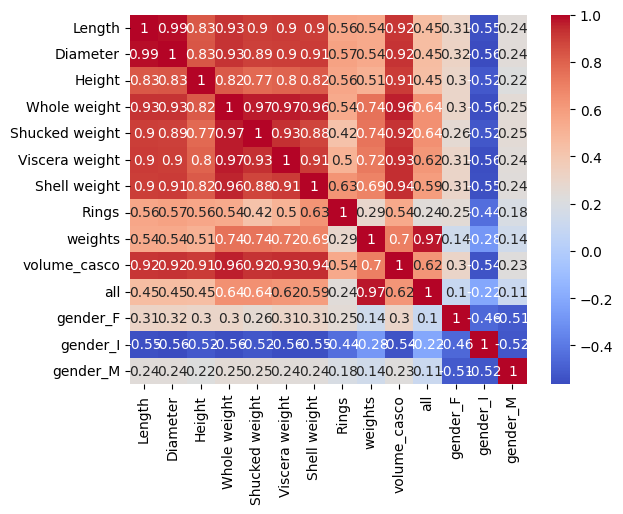

In [746]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')


In [747]:
y = df['Rings']

X = df[['gender_F', 'gender_M', 'gender_I', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']]
X_2 = df[['gender_F', 'gender_M', 'gender_I', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight', 'volume_casco', 'weights', 'all']]

In [748]:
algoritmo_ml = linear_model.LinearRegression()

sfs = SequentialFeatureSelector(algoritmo_ml, n_features_to_select='auto', direction='forward', scoring='r2', cv=5)
sfs.fit(X_2, y)

features_selecionadas = X_2.columns[sfs.get_support()]
X_3 = df[features_selecionadas]
X_3.head()

,gender_I,Diameter,Whole weight,Shucked weight,Viscera weight,Shell weight
0,0.0,0.365,0.5140,0.2245,0.1010,0.150
1,0.0,0.265,0.2255,0.0995,0.0485,0.070
2,0.0,0.420,0.6770,0.2565,0.1415,0.210
3,0.0,0.365,0.5160,0.2155,0.1140,0.155
4,1.0,0.255,0.2050,0.0895,0.0395,0.055


In [ ]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y, test_size=0.2, random_state=42)

sc3 = StandardScaler()
X_tr_s3 = sc3.fit_transform(X_train_3)

k_valores = range(1, 100)
scores_k = []

for k in k_valores:
    knn_temp = KNeighborsRegressor(n_neighbors=k)
    vazio = cross_val_score(knn_temp, X_tr_s3, y_train_3, cv=5, scoring='r2')
    scores_k.append(vazio.mean())

melhor_k = k_valores[np.argmax(scores_k)]
print(f"O melhor valor de k: {melhor_k}")

O melhor valor de k fixo é: 23


In [751]:
# Variáveis auxiliares
scores = {
    'reg': [], 'reg2': [], 'reg3': [],
    'reg_norm': [], 'reg2_norm': [], 'reg3_norm': [],
    'knn': [], 'knn2': [], 'knn3': [],
    'knn_norm': [], 'knn2_norm': [], 'knn3_norm': []
}

for i in range(1000):
    # Separando treino teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y, test_size=0.2)
    X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y, test_size=0.2)

    # Normalizando os dados
    sc1, sc2, sc3 = StandardScaler(), StandardScaler(), StandardScaler()

    X_tr_s1 = sc1.fit_transform(X_train)
    X_te_s1 = sc1.transform(X_test)
    
    X_tr_s2 = sc2.fit_transform(X_train_2)
    X_te_s2 = sc2.transform(X_test_2)
    
    X_tr_s3 = sc3.fit_transform(X_train_3)
    X_te_s3 = sc3.transform(X_test_3)

    # Ajustando modelos

    # Reg
    r1 = linear_model.LinearRegression().fit(X_train, y_train)
    r2 = linear_model.LinearRegression().fit(X_train_2, y_train_2)
    r3 = linear_model.LinearRegression().fit(X_train_3, y_train_3)

    # Knn
    k1 = KNeighborsRegressor(n_neighbors=melhor_k).fit(X_train, y_train)
    k2 = KNeighborsRegressor(n_neighbors=melhor_k).fit(X_train_2, y_train_2)
    k3 = KNeighborsRegressor(n_neighbors=melhor_k).fit(X_train_3, y_train_3)

    kn1 = KNeighborsRegressor(n_neighbors=melhor_k).fit(X_tr_s1, y_train)
    kn2 = KNeighborsRegressor(n_neighbors=melhor_k).fit(X_tr_s2, y_train_2)
    kn3 = KNeighborsRegressor(n_neighbors=melhor_k).fit(X_tr_s3, y_train_3)

    # Salvando score dos modelos na iteração
    scores['reg'].append(r1.score(X_test, y_test))
    scores['reg2'].append(r2.score(X_test_2, y_test_2))
    scores['reg3'].append(r3.score(X_test_3, y_test_3))

    scores['knn'].append(k1.score(X_test, y_test))
    scores['knn2'].append(k2.score(X_test_2, y_test_2))
    scores['knn3'].append(k3.score(X_test_3, y_test_3))
    
    scores['knn_norm'].append(kn1.score(X_te_s1, y_test))
    scores['knn2_norm'].append(kn2.score(X_te_s2, y_test_2))
    scores['knn3_norm'].append(kn3.score(X_te_s3, y_test_3))
    

In [752]:
# Exibir Formato Tabela
df_resultados = pd.DataFrame({
    'Modelo': ['Regressão 1 (Base)', 'Regressão 2 (Interação)', 'Regressão 3 (SFS)', 
               'KNN 1 (Base)', 'KNN 2 (Interação)', 'KNN 3 (SFS)'],
    'Score Bruto': [
        np.mean(scores['reg']), np.mean(scores['reg2']), np.mean(scores['reg3']),
        np.mean(scores['knn']), np.mean(scores['knn2']), np.mean(scores['knn3'])
    ],
    'Score Normalizado': [
        np.mean(scores['reg_norm']), np.mean(scores['reg2_norm']), np.mean(scores['reg3_norm']),
        np.mean(scores['knn_norm']), np.mean(scores['knn2_norm']), np.mean(scores['knn3_norm'])
    ]
})

display(df_resultados.style.highlight_max(axis=0, color='lightgreen'))

,Modelo,Score Bruto,Score Normalizado
0,Regressão 1 (Base),0.525983,nan
1,Regressão 2 (Interação),0.532208,nan
2,Regressão 3 (SFS),0.529727,nan
3,KNN 1 (Base),0.534548,0.520032
4,KNN 2 (Interação),0.531534,0.508747
5,KNN 3 (SFS),0.548917,0.542724


## Exercício

### 1) O modelo que apresentou o melhor desempenho foi o KNN regressor com a seleção de features sem estarem normalizadas. O KNN desempenhou melhor que o regressor, pois o regressor assume que existe uma reta que define a quantidade de anéis com base nas variáveis explicativas; se esse relacionamento não é linear — por exemplo, determinadas faixas de peso e tamanho fazem ter mais ou menos anéis. O SFS foi melhor do que o base e com variáveis de interações pois o ruído de variáveis multicolineares foi reduzido, e diminuir a dimensionalidade (reduzir o número de variáveis explicativas) ajuda o KNN a calcular distâncias mais coerentes com o método euclidiano. O modelo treinado sem normalizar os dados pode ter performado melhor pois, coincidentemente, a variável que tinha uma escala maior também era mais correlacionada com o número de anéis; ao normalizar, essa influência pode ter reduzido a influência dela.

### 2) Por mais que a diferência não tenha sido relevante é intuitivo que se escolha o modelo com maior acurácia, nesse caso o KNN regressor com SFS não normalizado.